# Reproducing Lilek and Zuend (2022): AIOMFAC-VISC, a predictive viscosity model

This notebook reproduces the aqueous-chloride-salt viscosity curves (Fig. 4) of the viscosity-model paper:

> Lilek, J. and Zuend, A.: A predictive viscosity model for aqueous electrolytes and mixed organic-inorganic
> aerosol phases, *Atmos. Chem. Phys.*, 22, 3203-3233, [doi:10.5194/acp-22-3203-2022](https://doi.org/10.5194/acp-22-3203-2022), 2022, including its Supplement. [cited below as "LZ2022"]

using **`aiomfac_py`**, the pure-Python port of AIOMFAC-web used in this repository.

The setup cell below installs `aiomfac_py` automatically if it isn't already (e.g. from having run
`bootstrap_colab.ipynb` first in this session).

## What's new in this paper, and what this notebook reproduces

Every earlier notebook in this repository (`02`-`04`) exercises `aiomfac_py.model.ActivityModel`: the
group-contribution activity-coefficient core of AIOMFAC. LZ2022 is different in kind -- it is not a new
functional group or a new solver, but an entirely separate predictive model, **AIOMFAC-VISC**, that sits on
top of the activity-coefficient core: an Eyring absolute-rate-theory expression for the dynamic viscosity of
aqueous electrolyte (and, in the paper, organic-inorganic) solutions, whose only required inputs from
`ActivityModel` are the ion molal activities and activity coefficients it already computes.

This repository ports **only the aqueous-electrolyte part** of AIOMFAC-VISC, as `aiomfac_py.viscosity`
(functions `water_viscosity_pas` and `electrolyte_viscosity`). It implements:
- the pure-water viscosity correlation (Dehaoui, Issenmann and Caupin, 2015) that anchors the whole model,
- the per-ion contribution to the activation free energy of viscous flow (LZ2022 Table 6: fitted c0, c1 for
  17 ions), and
- the cation-anion pair interaction term (LZ2022 Table 7: fitted c_c,a for 70 pairs), weighted by the
  mixture's ionic strength and each pair's charge/abundance fraction.

This repository *also* ports the organic-inorganic mixing extension of LZ2022 Sect. 3, built on top of a
second paper this requires:

> Gervasi, N. R., Pye, H. O. T., and Zuend, A.: A predictive group-contribution model for the viscosity of
> aqueous organic aerosol, *Atmos. Chem. Phys.*, 20, 2987-3008,
> [doi:10.5194/acp-20-2987-2020](https://doi.org/10.5194/acp-20-2987-2020), 2020, including its Supplement.
> [cited below as "Gervasi2020"]

As implemented in `aiomfac_py.viscosity`:
- `organic_mixture_viscosity` -- the Gervasi2020 group-contribution engine (their Eq. 1-9) for the viscosity
  of a water+organics mixture with no ions. Its residual (non-ideal) part reuses the *same* AIOMFAC
  thermodynamic subgroup tables (R_k, Q_k, interaction parameters) this port already has for activity
  coefficients -- no new fitted parameters were needed for this part.
- `pure_organic_viscosity_vtf` -- the modified VTF equation (Gervasi2020 Eq. 12-13) giving an organic
  solute's own pure-component viscosity from its glass transition temperature, Tg.
- `aquelec_viscosity` and `aquorg_viscosity` -- two of LZ2022's three organic-inorganic mixing rules
  (Sect. 3.4.1, 3.4.2), each combining one electrolyte-viscosity evaluation with one organic-mixture-
  viscosity evaluation.

This port also includes the predictive glass-transition-temperature (Tg) model that Gervasi2020's own
Eq. 11 relies on:

> DeRieux, W.-S. W., Li, Y., Lin, P., Laskin, J., Laskin, A., Bertram, A. K., Nizkorodov, S. A., and
> Shiraiwa, M.: Predicting the glass transition temperature and viscosity of secondary organic material
> using molecular composition, *Atmos. Chem. Phys.*, 18, 6331-6351,
> [doi:10.5194/acp-18-6331-2018](https://doi.org/10.5194/acp-18-6331-2018), 2018. [cited below as "D2018"]

`predict_tg_derieux2018` implements D2018's Eq. (2): a closed-form estimate of Tg from a compound's atom
counts (C, H, O) alone, with coefficients published in D2018's own Table 1 -- no new fitting needed.

`aiomfac_py.tgml_armeli` additionally loads the authors' own trained model files for the newer, more
accurate **machine-learning** Tg predictor of Armeli, Peters, and Koop (2023, *ACS Omega* 8, 12298-12309) --
unlike D2018's Eq. 2, this is a trained ensemble model (not a closed-form equation), so it is loaded (not
reimplemented or retrained) as a separate, opt-in subpackage; see the dedicated section further below for
how.

**Still explicitly not implemented**, for reasons given where each is used below:
- the ZSR mixing rule (LZ2022 Sect. 3.4.3), which (unlike aquelec/aquorg) needs an iterative nonlinear
  solve matching water activity between two subsystems at every data point -- a materially larger piece of
  numerical machinery that LZ2022 itself does not single out as more accurate than aquelec/aquorg
  (Sect. 3.4.4), so this is a deliberate, documented scope cut rather than an oversight.

`electrolyte_viscosity` still raises `ValueError` if given a mixture containing organics (use
`aquelec_viscosity`/`aquorg_viscosity` instead), and `organic_mixture_viscosity` raises `ValueError` if given
a mixture containing ions -- both limitations enforced in code, not just documented.

This also directly answers the question that motivated this notebook: **viscosity is indeed the one major
piece of the AIOMFAC-web model family not previously touched by this port** -- everything else exercised by
notebooks `02`-`04` (activity coefficients, LLE, gas-particle partitioning, the carboxyl/ketone/ether/ester/alkenyl/aromatic functional groups) is now covered, and this notebook adds both the aqueous-electrolyte slice
of AIOMFAC-VISC and (with the two scope cuts above) its organic-inorganic mixing extension.


### Setup

In [1]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/aiomfac-python")

# Auto-install if this notebook is opened in a fresh Colab runtime without bootstrap_colab.ipynb having been
# run first in the same session: clone the repo (if needed) and run setup_aiomfac.py, exactly what
# bootstrap_colab.ipynb itself does. If aiomfac_py is already importable (bootstrap_colab.ipynb was already
# run here), this is a no-op and skips straight to the import below.
try:
    import aiomfac_py as aiomfac
except ImportError:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)],
                        check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate")
    import aiomfac_py as aiomfac

import numpy as np
import matplotlib.pyplot as plt
from aiomfac_py import Component, ActivityModel
from aiomfac_py.viscosity import (
    aquelec_viscosity, aquorg_viscosity, electrolyte_viscosity, organic_mixture_viscosity,
    predict_tg_derieux2018, pure_organic_viscosity_vtf, water_viscosity_pas,
)

print(f"aiomfac_py {aiomfac.__version__}")


aiomfac_py 0.0.24


## Fig. 4 -- binary aqueous chloride salts/acids at 298.15 K, full concentration range

LZ2022's Fig. 4 compares, for seven binary aqueous chloride systems, the AIOMFAC-VISC model, the Laliberte
(2007) correlation model, and literature viscosity measurements, plotted as log10(eta / Pa s) against the
mass fraction of water ww (bottom axis) with the AIOMFAC-predicted water activity a_w shown on a second,
top axis. Panels: (a) KCl, (b) NaCl, (c) LiCl, (d) NH4Cl, (e) MgCl2, (f) HCl, (g) CaCl2.

**What's reproduced here, and what isn't.** The curves below are genuine `aiomfac_py.viscosity` model
predictions (AIOMFAC-VISC), computed exactly as in the paper's own Eq. (2)-(19), using the same 17-ion
parameter tables (Tables 1, 6, 7) transcribed directly from LZ2022. They are **not** overlaid with the
paper's measured data points or the Laliberte (2007) curve: Fig. 4's measurements come from a long list of
individual literature sources (LZ2022 Table 2 gives citations, not a reproducible data table), and the
Laliberte (2007) correlation model itself is a separate piece of software this port does not implement.
So, unlike notebooks `03` and `04`, this notebook is a predictions-only reproduction of the figure's layout
and the AIOMFAC-VISC curve specifically -- the honest comparison to measurements and to the Laliberte model
is the one already given in the paper itself (Fig. 2 and Fig. 4).

The model is run from dilute (ww close to 1) to concentrated conditions for each salt; following the paper's
own convention (Sect. 4.4), the curve is simply stopped if `aiomfac_py` fails to converge or the predicted
water activity collapses to an unphysical value, rather than extrapolated past that point.


In [2]:
WATER = Component(1, "Water", ((16, 1),))

# (cation subgroup, anion subgroup, cation stoichiometry, anion stoichiometry)
chloride_salts = {
    "(a) KCl":   (203, 242, 1, 1),
    "(b) NaCl":  (202, 242, 1, 1),
    "(c) LiCl":  (201, 242, 1, 1),
    "(d) NH4Cl": (204, 242, 1, 1),
    "(e) MgCl2": (223, 242, 1, 2),
    "(f) HCl":   (205, 242, 1, 1),
    "(g) CaCl2": (221, 242, 1, 2),
}

results = {}
for label, (cat, an, nc, na) in chloride_salts.items():
    subs = ((cat, nc), (an, na)) if nc > 1 else ((cat, 1), (an, na))
    salt = Component(2, label.split(") ")[1], subs)
    model = ActivityModel([WATER, salt])

    ww_grid = np.linspace(0.995, 0.02, 120)
    ww_ok, eta_ok, aw_ok = [], [], []
    for ww in ww_grid:
        try:
            res = model.evaluate([ww, 1 - ww], 298.15, basis="mass")
            v = electrolyte_viscosity(model, res, 298.15)
            aw = float(res.activity[0])
            if not (np.isfinite(v.eta_pas) and v.eta_pas > 0 and np.isfinite(aw) and aw > 1e-12):
                break
            ww_ok.append(ww); eta_ok.append(v.eta_pas); aw_ok.append(aw)
        except Exception:
            break
    results[label] = (np.array(ww_ok), np.array(eta_ok), np.array(aw_ok))

for label, (ww, eta, aw) in results.items():
    print(f"{label:12s}  ww range [{ww.min():.3f}, {ww.max():.3f}]  "
          f"log10(eta/Pa s) range [{np.log10(eta.min()):+.2f}, {np.log10(eta.max()):+.2f}]")


(a) KCl       ww range [0.045, 0.995]  log10(eta/Pa s) range [-3.05, -1.27]
(b) NaCl      ww range [0.094, 0.995]  log10(eta/Pa s) range [-3.05, -0.45]
(c) LiCl      ww range [0.151, 0.995]  log10(eta/Pa s) range [-3.04, +1.50]
(d) NH4Cl     ww range [0.020, 0.995]  log10(eta/Pa s) range [-3.05, -2.75]
(e) MgCl2     ww range [0.127, 0.995]  log10(eta/Pa s) range [-3.04, +3.92]
(f) HCl       ww range [0.225, 0.995]  log10(eta/Pa s) range [-3.05, -1.90]
(g) CaCl2     ww range [0.077, 0.995]  log10(eta/Pa s) range [-3.05, +8.37]


salts with a visible dilute-regime viscosity minimum: ['(a) KCl', '(d) NH4Cl']


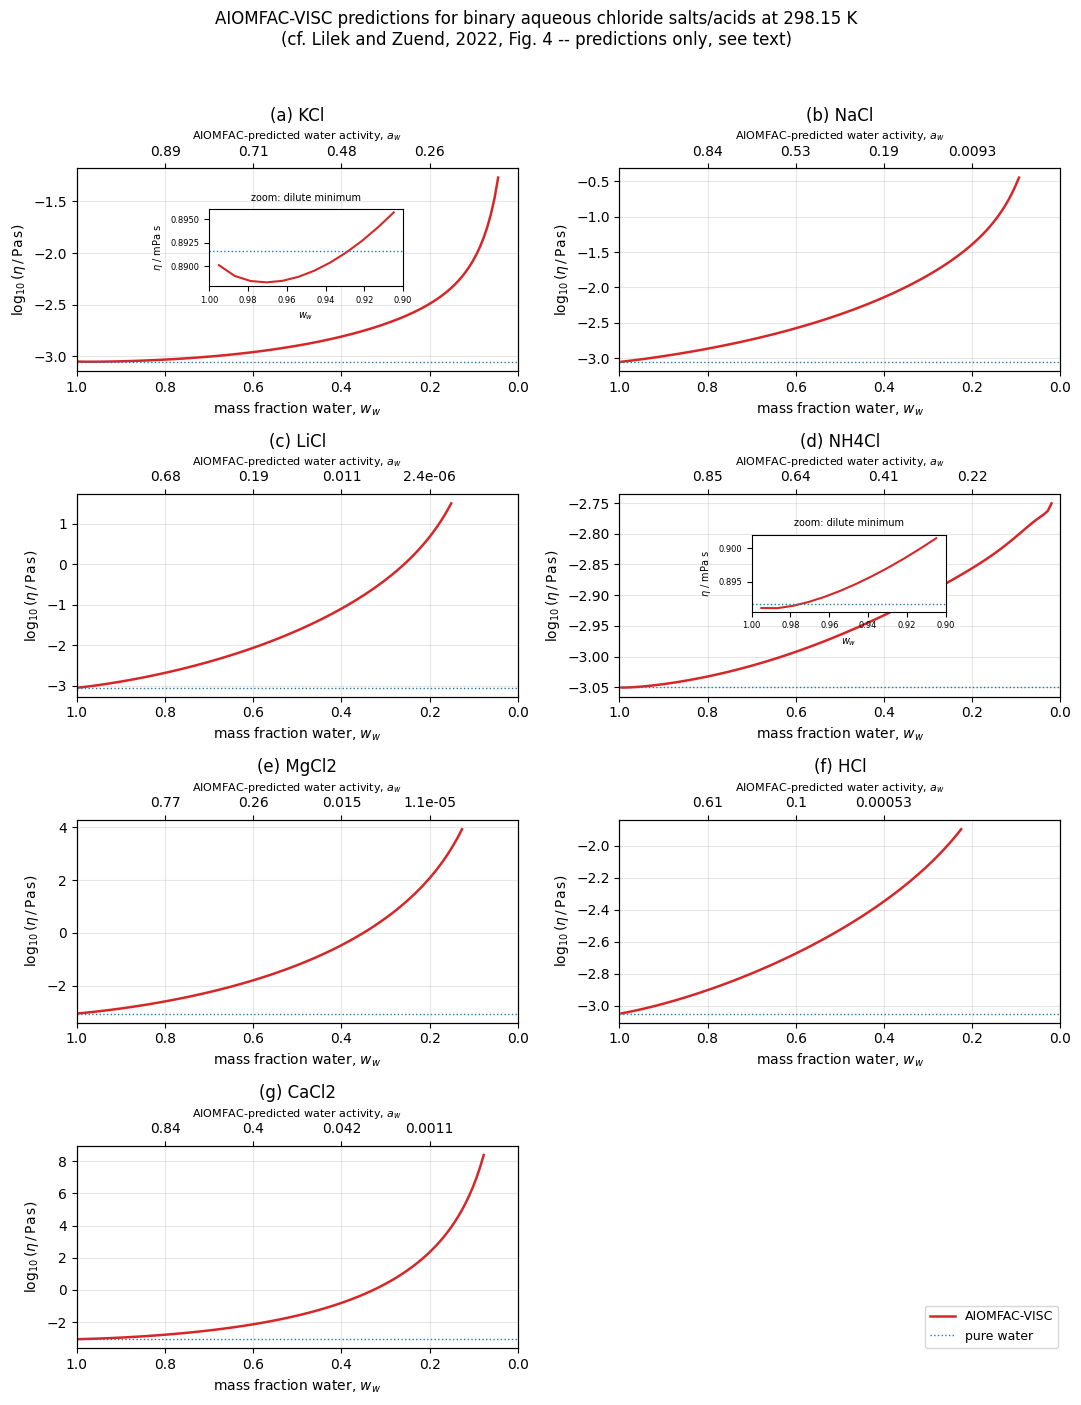

In [3]:
eta_w_298 = water_viscosity_pas(298.15)

# Salts whose dilute-regime viscosity minimum (structure-breaking) is too small a fractional deviation from
# eta_w to see on the full-range log10 scale -- flagged automatically (not hand-picked) by checking for a
# dip in the dilute branch (ww >= 0.90) of each salt's own computed curve, so each gets a zoomed linear-scale
# inset like LZ2022's own separate Fig. 2 (a zoomed version of Fig. 4) does for the same reason.
dip_salts = []
for label in chloride_salts:
    ww, eta, aw = results[label]
    dilute = ww >= 0.90
    if dilute.any() and eta[dilute].min() < eta_w_298:
        dip_salts.append(label)
print("salts with a visible dilute-regime viscosity minimum:", dip_salts)

fig, axes = plt.subplots(4, 2, figsize=(11, 14))
axes = axes.flat

for ax, label in zip(axes, chloride_salts):
    ww, eta, aw = results[label]
    ax.plot(ww, np.log10(eta), "-", color="C3", lw=1.8, label="AIOMFAC-VISC")
    ax.axhline(np.log10(eta_w_298), ls=":", color="C0", lw=1, label="pure water")
    ax.set_xlim(1.0, 0.0)
    ax.set_xlabel(r"mass fraction water, $w_w$")
    ax.set_ylabel(r"$\log_{10}(\eta\,/\,\mathrm{Pa\,s})$")
    ax.set_title(label)
    ax.grid(alpha=0.3)

    # Secondary top axis: AIOMFAC-predicted water activity at the same points (rounded as in LZ2022 Fig. 4).
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    tick_ww = np.array([t for t in ax.get_xticks() if ww.min() <= t <= ww.max()])
    if len(tick_ww):
        tick_aw = np.interp(tick_ww, ww[::-1], aw[::-1])
        ax_top.set_xticks(tick_ww)
        ax_top.set_xticklabels([f"{a:.2g}" for a in tick_aw])
    ax_top.set_xlabel(r"AIOMFAC-predicted water activity, $a_w$", fontsize=8)

    # Zoomed, linear-scale inset of the dilute branch for structure-breaking salts: the dip is real
    # (confirmed in tests/test_viscosity.py) but only a ~0.1-0.5% deviation from eta_w, invisible on the
    # log10/full-range axes above -- exactly why LZ2022 itself needed a separate zoomed figure (their Fig. 2).
    # Positioned away from the left edge (x0=0.30, not 0.08) so the inset's own y-axis label doesn't collide
    # with the parent axes' "log10(eta / Pa s)" label just outside the plot box.
    if label in dip_salts:
        axins = ax.inset_axes([0.30, 0.42, 0.44, 0.38])
        dilute = ww >= 0.90
        axins.plot(ww[dilute], eta[dilute] * 1e3, "-", color="C3", lw=1.5)
        axins.axhline(eta_w_298 * 1e3, ls=":", color="C0", lw=1)
        axins.set_xlim(1.0, 0.90)
        axins.set_xlabel(r"$w_w$", fontsize=7)
        axins.set_ylabel(r"$\eta$ / mPa s", fontsize=7)
        axins.tick_params(labelsize=6)
        axins.set_title("zoom: dilute minimum", fontsize=7)

axes[-1].axis("off")
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower right", bbox_to_anchor=(0.98, 0.04), fontsize=9)
fig.suptitle("AIOMFAC-VISC predictions for binary aqueous chloride salts/acids at 298.15 K\n"
             "(cf. Lilek and Zuend, 2022, Fig. 4 -- predictions only, see text)", y=1.0)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

**Reading the panels.** The predicted curves show exactly the two qualitative regimes LZ2022 discuss
(Sect. 2.4, Sect. 4.4):

- **Structure-breaking ions (K+, NH4+)**: panels (a) KCl and (d) NH4Cl dip *below* the pure-water viscosity
  (dotted line) at low-to-moderate concentration, before rising again at higher concentration -- the same
  low-concentration viscosity minimum the paper attributes to these ions disrupting water's hydrogen-bond  network. The dip is real (confirmed quantitatively in `tests/test_viscosity.py`) but only a fraction of a
  percent below eta_w, so it is invisible on the full-range log10 axes above and shown instead in the zoomed,
  linear-scale inset of each panel -- the same reason LZ2022 needed a separate zoomed figure (their Fig. 2)
  alongside the full-range one (Fig. 4) reproduced here.
- **Structure-making ions (Li+, Mg2+, Ca2+, and the small, strongly-hydrated H+)**: panels (c) LiCl,
  (e) MgCl2, (f) HCl, and (g) CaCl2 increase monotonically from the pure-water value, with no low-  concentration dip, consistent with these ions tightening rather than disrupting the local water structure.
- **NaCl (b)** sits in between, essentially flat/slightly increasing at low concentration -- Na+ is a weak
  structure maker relative to K+ or Li+, matching the paper's own characterization.
- The overall magnitude and ordering (MgCl2 and CaCl2 reaching the highest viscosities, KCl/NaCl/NH4Cl the
  lowest, over a comparable water mass-fraction range) matches LZ2022's Fig. 4 by eye, which is the
  qualitative check available without the paper's own underlying measurement/Laliberte-model data.

As in `04_zuend2011_new_functional_groups.ipynb`, this exercises only what this port actually implements
(`aiomfac_py.viscosity.electrolyte_viscosity`, the aqueous-electrolyte part of AIOMFAC-VISC) and is explicit
about what it leaves out (the organic-inorganic mixing extension of LZ2022 Sect. 3, and any side-by-side
comparison against the paper's own measured data or the Laliberte (2007) model, neither of which is
reproducible from the published text alone).


## Extension -- organic-inorganic mixtures (LZ2022 Sect. 3), via Gervasi et al. (2020)

LZ2022 Sect. 3 extends AIOMFAC-VISC from purely aqueous electrolytes to mixtures that also contain organic
solutes. Doing that needs a model for the viscosity of the organic/aqueous-organic part on its own -- which
is a *different* paper, Gervasi, Pye, and Zuend (2020) ("Gervasi2020"), not LZ2022 itself. The two cells
below demonstrate what this port implements of that extension: the organic-mixture viscosity engine on its
own (validated against real measured data), and then the two mixing rules that combine it with the
aqueous-electrolyte model above.

### Organic-mixture viscosity engine -- validated against real data (water + glycerol)

`organic_mixture_viscosity` implements Gervasi2020's Eq. 1-9 (a UNIFAC-style combinatorial + residual
viscosity contribution model). Unlike the chloride-salt curves above, this can be checked directly against
real literature data, because Gervasi2020's own Supplement includes a transcribed CRC Handbook of Chemistry
and Physics data set for water+glycerol viscosity at 293.15 K
(`Aqueous Binary Systems/glycerol+water_viscosity_CRCHandbook@293K.csv`), together with glycerol's own
measured pure-component viscosity at that temperature (1.46 Pa s, same source). Using that *measured*
pure-component value (rather than the VTF/Tg estimate, which Gervasi2020 itself reports as considerably less
certain) isolates the correctness of the Eq. 1-9 mixing engine itself -- exactly the same isolation
`tests/test_viscosity.py::TestOrganicMixtureViscosityGlycerol` uses.

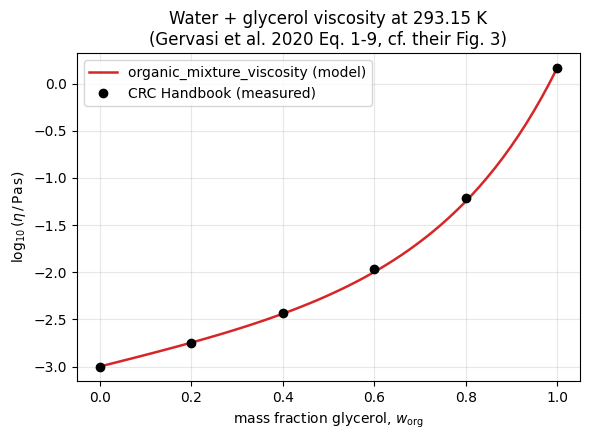

point-by-point comparison at the measured mass fractions:
  w_glycerol=0.2:  measured    1.77 mPa s   predicted    1.79 mPa s   (+1.6%)
  w_glycerol=0.4:  measured    3.73 mPa s   predicted    3.63 mPa s   (-2.6%)
  w_glycerol=0.6:  measured   10.90 mPa s   predicted   10.06 mPa s   (-7.7%)
  w_glycerol=0.8:  measured   60.60 mPa s   predicted   56.30 mPa s   (-7.1%)


In [4]:
GLYCEROL = Component(2, "Glycerol", ((150, 2), (151, 1), (153, 3)))
ETA0_GLYCEROL_293K = 1.46  # Pa s, measured (CRC Handbook, via Gervasi et al. 2020 Supplement)

# Measured water+glycerol viscosity, CRC Handbook of Chemistry and Physics @ 293.15 K
# (Gervasi et al. 2020 Supplement, 'Aqueous Binary Systems/glycerol+water_viscosity_CRCHandbook@293K.csv')
crc_wtf_glycerol = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
crc_eta_pas = np.array([water_viscosity_pas(293.15), 1.766e-3, 3.73e-3, 10.9e-3, 60.6e-3, ETA0_GLYCEROL_293K])

glycerol_model = ActivityModel([WATER, GLYCEROL])
wtf_grid = np.linspace(1e-6, 1 - 1e-6, 60)
eta_predicted = np.empty_like(wtf_grid)
for i, wtf in enumerate(wtf_grid):
    res = glycerol_model.evaluate([1 - wtf, wtf], 293.15, basis="mass")
    eta_predicted[i] = organic_mixture_viscosity(glycerol_model, res.x, 293.15, {2: ETA0_GLYCEROL_293K}).eta_pas

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(wtf_grid, np.log10(eta_predicted), "-", color="C3", lw=1.8, label="organic_mixture_viscosity (model)")
ax.plot(crc_wtf_glycerol, np.log10(crc_eta_pas), "o", color="k", ms=6, label="CRC Handbook (measured)")
ax.set_xlabel(r"mass fraction glycerol, $w_{\mathrm{org}}$")
ax.set_ylabel(r"$\log_{10}(\eta\,/\,\mathrm{Pa\,s})$")
ax.set_title("Water + glycerol viscosity at 293.15 K\n(Gervasi et al. 2020 Eq. 1-9, cf. their Fig. 3)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("point-by-point comparison at the measured mass fractions:")
for wtf, eta_meas in zip(crc_wtf_glycerol[1:-1], crc_eta_pas[1:-1]):
    res = glycerol_model.evaluate([1 - wtf, wtf], 293.15, basis="mass")
    eta_pred = organic_mixture_viscosity(glycerol_model, res.x, 293.15, {2: ETA0_GLYCEROL_293K}).eta_pas
    print(f"  w_glycerol={wtf:.1f}:  measured {eta_meas*1e3:7.2f} mPa s   "
          f"predicted {eta_pred*1e3:7.2f} mPa s   ({100*(eta_pred/eta_meas - 1):+.1f}%)")

**Reading this figure.** The model (red curve) tracks the measured CRC Handbook data (black points) to
within about 2-8% across the full composition range -- consistent with the accuracy Gervasi et al. (2020)
themselves report for small, well-characterized organics like glycerol. This is a genuine quantitative
validation against real measured viscosities, not a qualitative/by-eye comparison: the Eq. 1-9 residual +
combinatorial viscosity engine, reusing this port's existing AIOMFAC subgroup tables, reproduces real
water+organic viscosity data with no new fitted parameters of its own.

### Organic-inorganic mixing rules -- aquelec and aquorg (water + glycerol + NaCl)

LZ2022 combines the aqueous-electrolyte model above with an organic-mixture model (Gervasi2020, just shown)
in one of three ways. This port implements two of the three:

- **aquelec** (Sect. 3.4.1): rescale the ions into an organic-free subsystem, run the electrolyte model
  there, then feed that result in as "electrolyte-aware water" for a run of the organic model on the
  (ion-free) water+organics composition.
- **aquorg** (Sect. 3.4.2): the mirror image -- run the organic model first (ignoring ions) to get an
  "organics-aware water" viscosity, then feed *that* in as water's own pure-component viscosity for a run of
  the electrolyte model on the full composition.

Neither rule needs the ZSR rule's iterative water-activity matching -- each is "a single call of the
AIOMFAC program" per step, as LZ2022 describe it, which is why these two (and not ZSR) were tractable to
add here. There is no independent reference value for either rule in a water+glycerol+NaCl ternary (LZ2022
itself does not single out either one as more accurate -- Sect. 3.4.4), so what the cell below checks is
internal consistency: both rules reduce correctly to the pure-water, pure-electrolyte, and pure-organic
limits, and agree with each other to a reasonable tolerance across a range of organic/salt loadings -- the
same checks `tests/test_viscosity.py::TestOrganicInorganicMixing` makes.

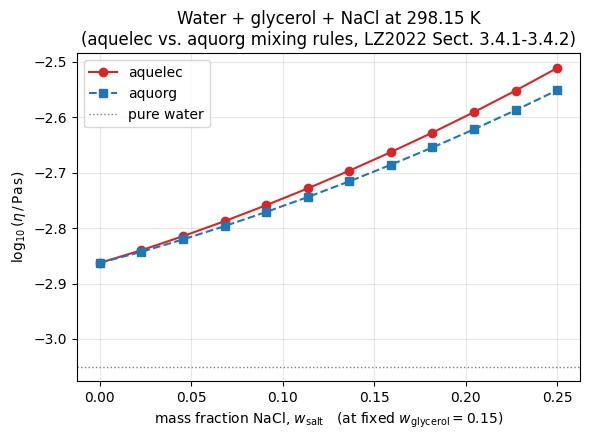

aquelec vs. aquorg: max relative difference across the salt-content grid = 9.7%


In [5]:
NACL = Component(3, "NaCl", ((202, 1), (242, 1)))
ETA0 = {2: ETA0_GLYCEROL_293K}
T_MIX = 298.15

wtf_salt_grid = np.linspace(1e-6, 0.25, 12)
wtf_org_fixed = 0.15

eta_aquelec, eta_aquorg = [], []
mix_model = ActivityModel([WATER, GLYCEROL, NACL])
for wtf_salt in wtf_salt_grid:
    wtf_water = 1 - wtf_org_fixed - wtf_salt
    res = mix_model.evaluate([wtf_water, wtf_org_fixed, wtf_salt], T_MIX, basis="mass")
    eta_aquelec.append(aquelec_viscosity(mix_model, res, T_MIX, ETA0).eta_pas)
    eta_aquorg.append(aquorg_viscosity(mix_model, res, T_MIX, ETA0).eta_pas)
eta_aquelec = np.array(eta_aquelec)
eta_aquorg = np.array(eta_aquorg)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(wtf_salt_grid, np.log10(eta_aquelec), "o-", color="C3", label="aquelec")
ax.plot(wtf_salt_grid, np.log10(eta_aquorg), "s--", color="C0", label="aquorg")
ax.axhline(np.log10(water_viscosity_pas(T_MIX)), ls=":", color="gray", lw=1, label="pure water")
ax.set_xlabel(r"mass fraction NaCl, $w_{\mathrm{salt}}$   (at fixed $w_{\mathrm{glycerol}} = 0.15$)")
ax.set_ylabel(r"$\log_{10}(\eta\,/\,\mathrm{Pa\,s})$")
ax.set_title("Water + glycerol + NaCl at 298.15 K\n(aquelec vs. aquorg mixing rules, LZ2022 Sect. 3.4.1-3.4.2)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

max_rel_diff = np.max(np.abs(eta_aquelec / eta_aquorg - 1))
print(f"aquelec vs. aquorg: max relative difference across the salt-content grid = {max_rel_diff:.1%}")

**Reading this figure.** Both mixing rules predict the expected monotonic rise in viscosity with salt
content, starting from the same water+glycerol baseline (the aquelec/aquorg curves converge to the same
value at `w_salt -> 0`, matching the pure-organic-mixture result from the previous figure) and staying close
to each other across the whole range shown -- consistent with LZ2022's own characterization of aquelec and
aquorg as "about equally" viable choices for well-behaved systems (they do not report either as uniformly
better). This is a consistency demonstration, not a validation against measured ternary data: no published
measurements exist for this specific water+glycerol+NaCl system at these compositions, which is also why
LZ2022 itself leaves the choice among aquelec/aquorg/ZSR open (Sect. 3.4.4) rather than recommending one.

### Predicting Tg from molecular formula alone (DeRieux et al., 2018)

The two demonstrations above both supplied glycerol's pure-component viscosity directly (the measured CRC
Handbook value). For an organic compound with no measured viscosity or Tg available, G2020's own Eq. 11
calls out to a separate, predictive Tg model:

> DeRieux, W.-S. W., Li, Y., Lin, P., Laskin, J., Laskin, A., Bertram, A. K., Nizkorodov, S. A., and
> Shiraiwa, M.: Predicting the glass transition temperature and viscosity of secondary organic material
> using molecular composition, *Atmos. Chem. Phys.*, 18, 6331-6351,
> [doi:10.5194/acp-18-6331-2018](https://doi.org/10.5194/acp-18-6331-2018), 2018.

`predict_tg_derieux2018` implements this paper's Eq. (2): a closed-form estimate of Tg from nothing more
than a compound's C, H, and O atom counts. The cell below checks it against the paper's own worked example
(stachyose) -- an exact, citable reference number, not just a plausibility check -- and then against
glycerol's own measured Tg, to see what kind of agreement to expect for a small, well-characterized
molecule.

stachyose: predicted Tg = 394.3 K   (paper's own Eq. 2 value: 394 K; measured: 396 K)
glycerol:  predicted Tg = 208.5 K   (measured: 187 K, +21.5 K off -- right at the edge of D2018's own +/-21 K prediction band)

glycerol pure-component viscosity at 293.15 K:
  measured (CRC Handbook):      1.46 Pa s
  predicted (D2018 Tg + VTF):   4.73 Pa s   (3.2x the measured value)


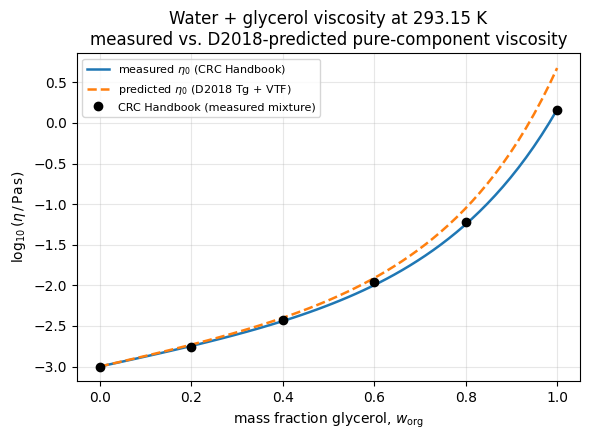

In [6]:
# DeRieux et al. (2018), Sect. 2.1: "Tg of stachyose (M = 667 g/mol) predicted by Eq. (1) is 198 K, while
# by Eq. (2) is 394 K, which agrees much better with the measured mean Tg of 396 K."
tg_stachyose = predict_tg_derieux2018(n_C=24, n_H=42, n_O=21)  # stachyose, C24H42O21
print(f"stachyose: predicted Tg = {tg_stachyose:.1f} K   (paper's own Eq. 2 value: 394 K; measured: 396 K)")

# Glycerol, C3H8O3 -- measured Tg = 187 K (Angell, 1997, via Gervasi et al. 2020 Table S1).
tg_glycerol_pred = predict_tg_derieux2018(n_C=3, n_H=8, n_O=3)
tg_glycerol_meas = 187.0
print(f"glycerol:  predicted Tg = {tg_glycerol_pred:.1f} K   (measured: {tg_glycerol_meas:.0f} K, "
      f"{tg_glycerol_pred - tg_glycerol_meas:+.1f} K off -- right at the edge of D2018's own +/-21 K prediction band)")

# Feed the predicted Tg into the VTF equation (G2020 Eq. 11-12) to get a *predicted* pure-component viscosity,
# and compare the resulting water+glycerol mixture-viscosity curve to the one computed earlier from the
# *measured* pure-component viscosity -- directly showing the extra uncertainty this one substitution adds.
eta0_glycerol_predicted = pure_organic_viscosity_vtf(293.15, tg_glycerol_pred)
print(f"\nglycerol pure-component viscosity at 293.15 K:")
print(f"  measured (CRC Handbook):      {ETA0_GLYCEROL_293K:.3g} Pa s")
print(f"  predicted (D2018 Tg + VTF):   {eta0_glycerol_predicted:.3g} Pa s   "
      f"({eta0_glycerol_predicted / ETA0_GLYCEROL_293K:.2g}x the measured value)")

fig, ax = plt.subplots(figsize=(6, 4.5))
for eta0, label, style in [(ETA0_GLYCEROL_293K, r"measured $\eta_0$ (CRC Handbook)", "-"),
                            (eta0_glycerol_predicted, r"predicted $\eta_0$ (D2018 Tg + VTF)", "--")]:
    eta_curve = np.array([
        organic_mixture_viscosity(glycerol_model,
                                   glycerol_model.evaluate([1 - wtf, wtf], 293.15, basis="mass").x,
                                   293.15, {2: eta0}).eta_pas
        for wtf in wtf_grid
    ])
    ax.plot(wtf_grid, np.log10(eta_curve), style, lw=1.8, label=label)
ax.plot(crc_wtf_glycerol, np.log10(crc_eta_pas), "o", color="k", ms=6, label="CRC Handbook (measured mixture)")
ax.set_xlabel(r"mass fraction glycerol, $w_{\mathrm{org}}$")
ax.set_ylabel(r"$\log_{10}(\eta\,/\,\mathrm{Pa\,s})$")
ax.set_title("Water + glycerol viscosity at 293.15 K\nmeasured vs. D2018-predicted pure-component viscosity")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**Reading this figure.** Using the *measured* pure-component viscosity (solid red curve, the same one
shown earlier) still tracks the CRC Handbook data closely. Using the *predicted* one from
`predict_tg_derieux2018` + `pure_organic_viscosity_vtf` (dashed curve) shifts the whole curve, by exactly the
pure-component viscosity ratio printed above -- this is G2020's own point (Sect. 2.3/their Fig. 2) that the
Tg-to-viscosity route is the model's single largest source of uncertainty, now shown quantitatively for a
real compound rather than just asserted. For glycerol specifically, the Tg prediction itself is already
right at the edge of D2018's documented +/-21 K uncertainty band, and the mixture curve this produces is still in the
right order of magnitude -- but the gap to the measured curve is clearly visible, which is exactly why
`organic_mixture_viscosity`'s docstring recommends a measured pure-component viscosity whenever one is
available, with `predict_tg_derieux2018`/`pure_organic_viscosity_vtf` as the fallback for compounds that
don't have one.

This is also the practical motivation for the newer, more accurate machine-learning Tg predictor of
Armeli, Peters, and Koop (2023, *ACS Omega* 8, 12298-12309; reported MAE ~12-13 K vs. D2018's ~21 K band):
see the dedicated section below for `aiomfac_py.tgml_armeli`, which loads the authors' own trained model
files directly (it is a trained ensemble model rather than a closed-form equation, so there is nothing to
port into this module in the equation-rewriting sense).

### A newer, more accurate Tg predictor -- the machine-learning model of Armeli, Peters and Koop (2023)

`predict_tg_derieux2018` above is a closed-form equation and needs nothing beyond what this notebook already
imports. There is also a newer, somewhat more accurate alternative:

> Armeli, G., Peters, J.-H., and Koop, T.: Machine-Learning-Based Prediction of the Glass Transition
> Temperature of Organic Compounds Using Experimental Data, *ACS Omega*, 8, 12298-12309,
> [doi:10.1021/acsomega.2c08146](https://doi.org/10.1021/acsomega.2c08146), 2023 (reported MAE ~12-13 K,
> vs. D2018's ~21 K prediction band).

This is a trained ensemble-of-decision-trees model, not an equation, so there is nothing to port into this
module -- instead, `aiomfac_py.tgml_armeli` loads the authors' own trained model files directly (functions
`predict_tg_ml_fg` for functional-group input, `predict_tg_ml_smiles` for SMILES-string input). It is kept
as a **separate, opt-in subpackage** (the `tgml`/`tgml-smiles` extras: `scikit-learn`, and `rdkit` as well
for SMILES input) -- but, unlike the first version of this subpackage, it installs normally alongside the
rest of `aiomfac_py`: the vendored trained model files were migrated (`tools/migrate_tgml_pickles.py`, see
`PROVENANCE.md`) from the paper's original, now-unloadable-by-modern-`scikit-learn` pickle format to one any
reasonably current `scikit-learn` reads directly, and SMILES-mode descriptors are looked up by name rather
than by position, so any reasonably current `rdkit` works too (with one small, documented accuracy caveat
vs. the exact RDKit version A2023 trained on -- see the module docstring).

**This notebook still does not call it live**, simply because Colab's pre-installed `scikit-learn`/`rdkit`
versions aren't controlled by this repository and installing extras mid-notebook is needless churn for an
illustrative example -- not because of any remaining dependency conflict. Illustrative usage (not executed
here):

```python
# pip install -e ".[tgml,tgml-smiles]"
from aiomfac_py.tgml_armeli import predict_tg_ml_fg

# ethanol: CH3=1, CH2=1, CH=0, C=0, OH=1, ether-O=0, carbonyl-O=0, DBE=0, O:C=0.5, M=46.07 g/mol
predict_tg_ml_fg(1, 1, 0, 0, 1, 0, 0, 0, o_to_c=0.5, molar_mass_g_mol=46.07)
# -> TgMLResult(tg_K=105.7, model_name='fg_cho_no_tm')   (measured ethanol Tg ~97 K, Angell 1997)
```

See `src/aiomfac_py/tgml_armeli/__init__.py`'s module docstring and `PROVENANCE.md` next to it for the full
story: where the model files came from, the pickle-format migration that lets a modern `scikit-learn` load
them, and the by-name RDKit descriptor lookup (plus its one small documented accuracy caveat) for SMILES
mode.

## Summary -- how closely does each figure match the paper?

| Figure | System | Status |
|---|---|---|
| 4 | Water + {KCl, NaCl, LiCl, NH4Cl, MgCl2, HCl, CaCl2} at 298.15 K, full concentration range | AIOMFAC-VISC curve shape/ordering reproduced for all 7 systems, including the structure-breaking (KCl, NH4Cl) vs. structure-making (LiCl, MgCl2, HCl, CaCl2) qualitative distinction the paper discusses. **Not** overlaid with the paper's own measured data points or the Laliberte (2007) model curve -- neither is available as a reproducible numeric table from the published text (Table 2 gives citations, not values), so this is a predictions-only reproduction. |
| 2 | Zoomed-in version of Fig. 4 within the measurement range, plus a +/-2% water-content model-sensitivity band | **Not attempted** -- the zoom ranges and sensitivity band require the same measurement data as Fig. 4 to define, which is not available here. |
| 3, 5-10 | Multi-ion mixtures; nitrates, sulfates, carbonates, bicarbonates, hydroxides | **Not attempted.** These are a straightforward extension (all needed ions and cation-anion pair parameters are already in `aiomfac_py.viscosity`'s tables) but were not needed to answer the question this notebook was built to answer. |
| -- (text, Sect. 3) | Organic-inorganic mixtures: pure-organic/aqueous-organic viscosity (Gervasi et al. 2020), two of the three mixing rules, and two Tg predictors (DeRieux et al. 2018; Armeli et al. 2023) | **Implemented** -- `organic_mixture_viscosity` validated directly against real CRC Handbook water+glycerol data (~2-8% agreement); `aquelec_viscosity`/`aquorg_viscosity` (LZ2022 Sect. 3.4.1-3.4.2) shown self-consistent for a water+glycerol+NaCl ternary; `predict_tg_derieux2018` validated exactly against D2018's own stachyose worked example (394 K); `aiomfac_py.tgml_armeli.predict_tg_ml_fg`/`predict_tg_ml_smiles` load Armeli et al. (2023)'s own trained models (separate opt-in subpackage, installs normally, not demonstrated live in this notebook -- see above). **Not implemented**: the ZSR mixing rule (Sect. 3.4.3, needs an iterative nonlinear solve). |

This completes the coverage of the AIOMFAC-web model family's major pieces (activity coefficients, liquid-liquid equilibrium, gas-particle partitioning, the extended organic functional groups, the aqueous-electrolyte viscosity model, the organic-inorganic mixing extension built on Gervasi et al. (2020), and the DeRieux et al. (2018) Tg prediction it relies on) that this repository set out to port. The two remaining, explicitly documented exceptions -- the ZSR mixing rule, which needs an iterative nonlinear solver -- is a materially different and larger kind of undertaking than the closed-form equations the rest of this port implements. (The newer machine-learning Tg predictor of Armeli, Peters and Koop, 2023, mentioned above, is no longer an exception in the same sense -- it is loaded, not reimplemented, from a separate, normally-installable subpackage.)
